### Exploratory Data Anlysis

In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 02/27/26 14:31:11


In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
file_path = r"C:\Users\natex\Downloads\Air_Quality_20260227.csv"

In [4]:
# Read data file, make sure to identifier seperator
df = pd.read_csv(file_path)

In [5]:
# Display shape of dataframe
df.shape

(18862, 12)

In [6]:
# Display info about dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [7]:
# Display columns
df.columns

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [8]:
# Display data types
df.dtypes

Unique ID           int64
Indicator ID        int64
Name               object
Measure            object
Measure Info       object
Geo Type Name      object
Geo Join ID         int64
Geo Place Name     object
Time Period        object
Start_Date         object
Data Value        float64
Message           float64
dtype: object

In [9]:
# Display sample of 5 random rows
df.sample(5)

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
6231,605806,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF34,202,Downtown - Heights - Slope,Winter 2017-18,12/01/2017,9.380000,NaN
297,878153,386,Ozone (O3),Mean,ppb,CD,206,Belmont and East Tremont (CD6),Summer 2023,06/01/2023,32.734651,NaN
1644,825848,375,Nitrogen dioxide (NO2),Mean,ppb,CD,101,Financial District (CD1),Annual Average 2022,01/01/2022,20.964511,NaN
5263,605754,365,Fine particles (PM 2.5),Mean,mcg/m3,UHF42,403,Flushing - Clearview,Summer 2018,06/01/2018,8.350000,NaN
12627,166813,375,Nitrogen dioxide (NO2),Mean,ppb,CD,201,Mott Haven and Melrose (CD1),Summer 2012,06/01/2012,19.140000,NaN


In [10]:
# Check for missing values
df.isnull().sum()

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           18862
dtype: int64

In [11]:
# Display duplicated rows
df[df.duplicated(keep=False)]

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message


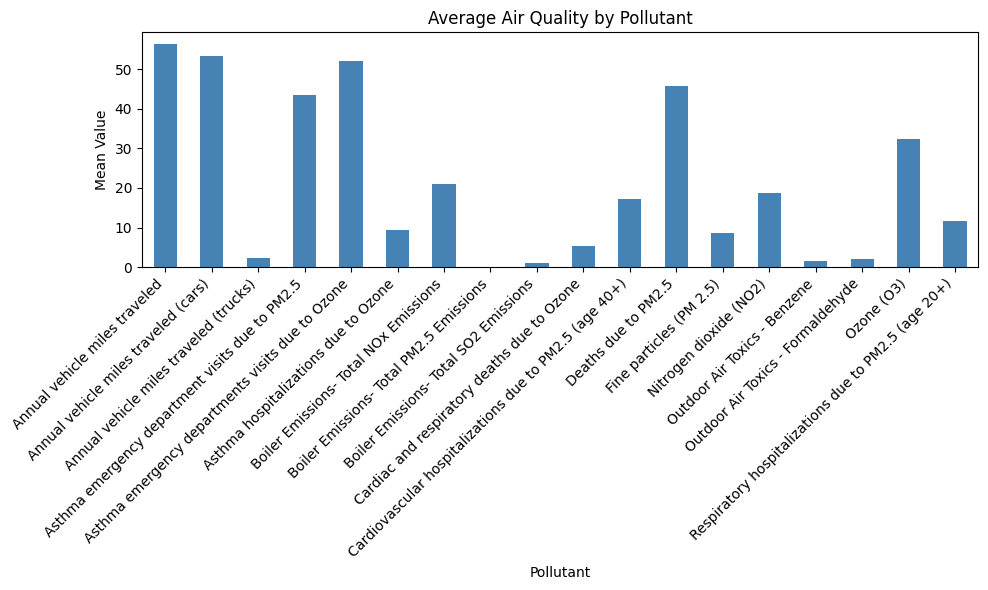

In [12]:
# Define IBX Neighborhood
# Map all variations to a single name
neighborhood_map = {
    'Canarsie - Flatlands': 'Canarsie',
    'Flatlands and Canarsie (CD18)': 'Canarsie',
    'East New York': 'East New York',
    'East New York and Starrett City (CD5)': 'East New York',
    'Bay Ridge and Dyker Heights (CD10)': 'Bay Ridge',
    'Bensonhurst - Bay Ridge': 'Bay Ridge',
    'Borough Park': 'Borough Park',
    'Borough Park (CD12)': 'Borough Park',
    'Ridgewood - Forest Hills': 'Ridgewood',
    'Ridgewood and Maspeth (CD5)': 'Ridgewood'
}
sliced = df[df['Geo Place Name'].isin(neighborhood_map.keys())].copy()

# Replace the neighborhood names
sliced['Geo Place Name'] = sliced['Geo Place Name'].map(neighborhood_map)

# Average Data Value per pollutant
grouped = sliced.groupby('Name')['Data Value'].mean()

grouped.plot(kind='bar', figsize=(10, 6), color='steelblue')

plt.title('Average Air Quality by Pollutant')
plt.xlabel('Pollutant')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
print(sliced['Name'].unique())

['Ozone (O3)' 'Fine particles (PM 2.5)' 'Nitrogen dioxide (NO2)'
 'Annual vehicle miles traveled' 'Annual vehicle miles traveled (trucks)'
 'Annual vehicle miles traveled (cars)'
 'Asthma emergency departments visits due to Ozone'
 'Asthma hospitalizations due to Ozone'
 'Asthma emergency department visits due to PM2.5'
 'Respiratory hospitalizations due to PM2.5 (age 20+)'
 'Cardiac and respiratory deaths due to Ozone' 'Deaths due to PM2.5'
 'Cardiovascular hospitalizations due to PM2.5 (age 40+)'
 'Boiler Emissions- Total SO2 Emissions'
 'Boiler Emissions- Total NOx Emissions'
 'Boiler Emissions- Total PM2.5 Emissions'
 'Outdoor Air Toxics - Formaldehyde' 'Outdoor Air Toxics - Benzene']


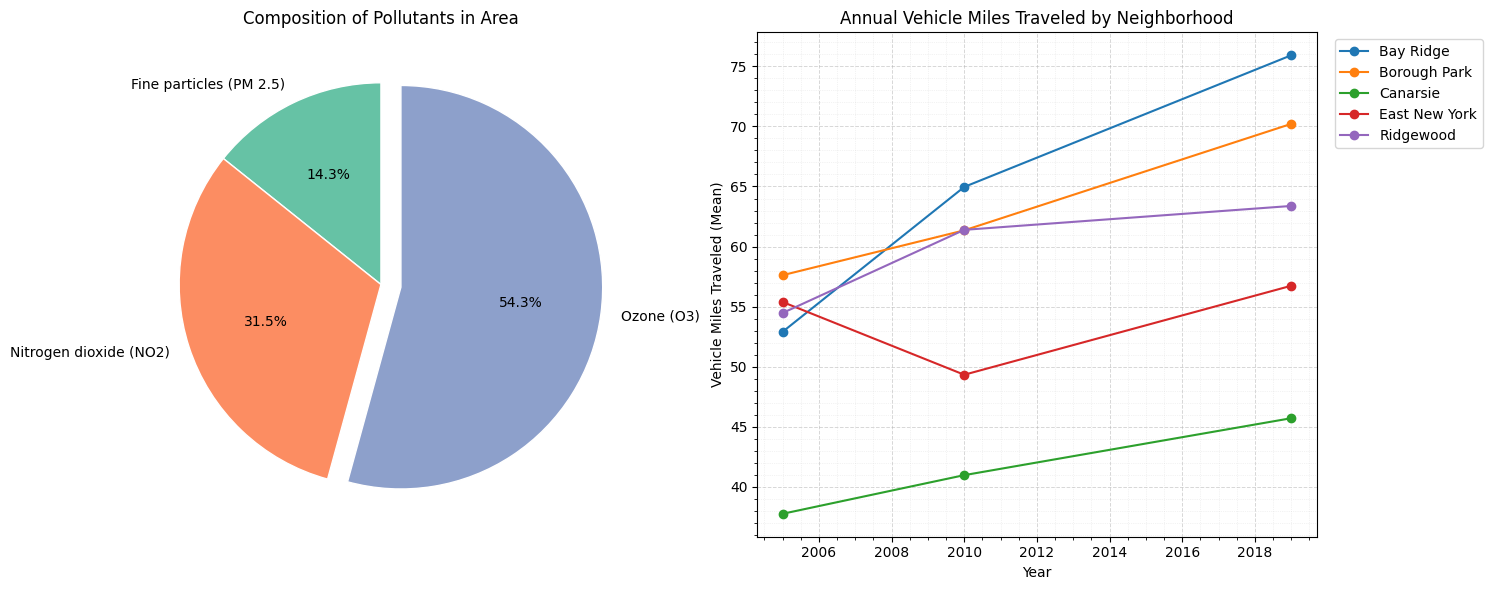

In [14]:
# ---------- DATA PREP (shared) ----------
sliced = df[df['Geo Place Name'].isin(neighborhood_map.keys())].copy()
sliced['Geo Place Name'] = sliced['Geo Place Name'].map(neighborhood_map)

sliced['Start_Date'] = pd.to_datetime(sliced['Start_Date'])
sliced['Year'] = sliced['Start_Date'].dt.year


# ---------- AIR POLLUTANTS (PIE CHART DATA) ----------
pollutants = sliced[sliced['Name'].isin([
    'Ozone (O3)',
    'Nitrogen dioxide (NO2)',
    'Fine particles (PM 2.5)'
])]

pollutant_avg = (
    pollutants
    .groupby('Name')['Data Value']
    .mean()
)


# ---------- VEHICLE MILES (LINE GRAPH DATA) ----------
vehicle = sliced[sliced['Name'] == 'Annual vehicle miles traveled']

vehicle_grouped = (
    vehicle
    .groupby(['Year', 'Geo Place Name'])['Data Value']
    .mean()
    .unstack()
)


# ---------- COMBINED FIGURE ----------
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, figsize=(15, 6)
)

# === LEFT: AIR POLLUTION PIE CHART ===
colors = plt.cm.Set2.colors  # ColorBrewer Set1 palette
explode = [
    0.1 if name == 'Ozone (O3)' else 0
    for name in pollutant_avg.index
]

ax1.pie(
    pollutant_avg,
    labels=pollutant_avg.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(pollutant_avg)],
    explode = explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

ax1.set_title('Composition of Pollutants in Area')

# === RIGHT: VEHICLE MILES LINE GRAPH ===
vehicle_grouped.plot(
    ax=ax2,
    marker='o'
)

ax2.minorticks_on()
ax2.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax2.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

ax2.set_title('Annual Vehicle Miles Traveled by Neighborhood')
ax2.set_xlabel('Year')
ax2.set_ylabel('Vehicle Miles Traveled (Mean)')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')


plt.tight_layout()
plt.show()